# E37 · Extreme-event attribution: how much did warming load the dice for the 2021 heatwave?

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | NOAA GHCN-Daily station records for **Seattle-Tacoma** (1948-2025) and **Portland** airport (1939-2025): the hottest day of every year · NASA **GISTEMP** v4 global mean temperature, 1880-2025 |
| **You will learn** | Block maxima and the **generalised extreme value** (GEV) distribution · why the **shape** parameter is the hard part (a negative shape = a hard upper limit) · `pymc_extras` `GenExtreme` checked against `scipy.stats.genextreme` (and its sign convention) · a geophysical shape prior and a prior predictive check in degrees · the **support wall**: why a GEV fit diverges and a reparametrisation that removes it · a **non-stationary** GEV whose location follows global temperature · return-level plots, PIT and LOO · the attribution quantities: **probability ratio**, return periods, intensity change · fitting **without the event, with it, and with it corrected for selection** · an event beyond the fitted upper bound, and reporting an **infinite** probability ratio honestly · replication at a second station and a **shared shape** · explaining it to everyone: icon arrays, "30-year mortgage" odds, an animated shifting climate, quantile dotplots |

## The question, in one paragraph

On 28 June 2021 the thermometer at Seattle-Tacoma airport read 108 °F (42.2 °C). In more than
seventy years of records it had never gone above 103 °F (39.4 °C); Portland, three hours
south, reached 116 °F (46.7 °C) the same day. Afterwards everyone asked the same two
questions. **Could a day like that have happened at all in the climate our grandparents
lived in? And if it could, how much more likely has the warming since then made it?** This
notebook answers both from the airport's own records of the hottest day of each year and
the world's average temperature. The answer turns out to have an honest twist: the old
records are so far below 108 °F that, for many of the explanations consistent with them,
such a day was not just rare but *impossible* - and we will have to say how many.

## The technical plan

Climate scientists answer this with **extreme-event attribution** (the World Weather
Attribution group did so within days for this event: Philip et al. 2022, *Earth System
Dynamics*). The recipe: take the most extreme value of each year (a *block maximum*), model
it with the distribution that extreme-value theory says block maxima must follow, let the
centre of that distribution move with global mean temperature, and compare the fitted
probability of the event in today's climate with its probability in a climate 1.2 °C
cooler (roughly the world before industrialisation). The ratio of the two is the
**probability ratio**; the difference in temperature for an event of the same rarity is the
**intensity change**. We do it Bayesianly, which turns out to matter most exactly where
the event breaks the fitted model.

In [1]:
import json
import logging
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Ellipse, Rectangle
from pymc_extras.distributions import GenExtreme
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 2021
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
logging.getLogger("pymc").setLevel(logging.WARNING)
# GenExtreme draws through scipy, so numba runs it in object mode (harmless, but noisy).
warnings.filterwarnings("ignore", message="Numba will use object mode")

# One hue per climate: blue for the cooler past, red for today; grey for data and reference lines.
PAST, NOW, GREY, INK = "#2a78d6", "#d6452a", "#8a8a86", "#222222"


def c_to_f(c):
    return np.asarray(c) * 9 / 5 + 32


def f_to_c(f):
    return (np.asarray(f) - 32) * 5 / 9


def add_f_axis(ax, which="x"):
    """A secondary axis in degrees Fahrenheit for an axis in degrees Celsius."""
    if which == "x":
        sec = ax.secondary_xaxis("top", functions=(c_to_f, f_to_c))
        sec.set_xlabel("°F")
    else:
        sec = ax.secondary_yaxis("right", functions=(c_to_f, f_to_c))
        sec.set_ylabel("°F")
    return sec


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data: the hottest day of every year

GHCN-Daily ships one file per station with every observation the station ever made, in
long format: date, element (`TMAX` is the day's maximum temperature in tenths of a
degree C), value and three flag columns. A blank *quality* flag means the value passed
NOAA's checks; we drop the rest (at Sea-Tac that is a single day out of 28,000).

In [2]:
data.describe("ghcnd_seatac")
data.describe("ghcnd_portland")
data.describe("gistemp_global")


def annual_maxima(name, min_days=355):
    """Hottest TMAX (deg C) of each year with at least `min_days` valid daily maxima."""
    raw = data.load(name)
    tmax = raw[(raw.element == "TMAX") & raw.qflag.isna()].copy()
    tmax["year"] = tmax.date.str[:4].astype(int)
    tmax["tmax_c"] = tmax.value / 10
    per_year = tmax.groupby("year").agg(days=("tmax_c", "size"), tmax_c=("tmax_c", "max"))
    hottest = tmax.loc[tmax.groupby("year").tmax_c.idxmax(), ["year", "date"]].set_index("year")
    per_year["date"] = pd.to_datetime(hottest.date).dt.strftime("%d %b")
    dropped = per_year[per_year.days < min_days]
    print(f"{name}: {len(per_year)} years, dropping {len(dropped)} incomplete: "
          + ", ".join(f"{y} ({d} days)" for y, d in dropped.days.items()))
    return per_year[per_year.days >= min_days]


sea = annual_maxima("ghcnd_seatac")
pdx = annual_maxima("ghcnd_portland")
print(sea.tail(3))
print("Sea-Tac hottest years:\n", sea.sort_values("tmax_c").tail(5)[["tmax_c", "date"]].T)

ghcnd_seatac: Every daily observation at Sea-Tac since 1948 in long format, no header: station id, date (YYYYMMDD), element (TMAX/TMIN in tenths of a degree C, PRCP, SNOW, ...), value, measurement / quality / source flags and observation time. A blank quality flag means the value passed NOAA's checks. The file is updated daily, so the latest year is partial.
  source: Menne et al. (2012), Global Historical Climatology Network - Daily (GHCN-Daily), NOAA National Centers for Environmental Information; station USW00024233 Seattle-Tacoma International Airport.
  url:    https://www.ncei.noaa.gov/pub/data/ghcn/daily/by_station/USW00024233.csv.gz
ghcnd_portland: Every daily observation at Portland airport since April 1938, same long format as ghcnd_seatac (TMAX in tenths of a degree C).
  source: Menne et al. (2012), Global Historical Climatology Network - Daily (GHCN-Daily), NOAA National Centers for Environmental Information; station USW00024229 Portland International Airport, Oregon.
  ur

ghcnd_portland: 89 years, dropping 2 incomplete: 1938 (275 days), 2026 (264 days)
      days  tmax_c    date
year                      
2023   365    35.0  15 Aug
2024   366    36.7  09 Jul
2025   365    34.4  16 Jul
Sea-Tac hottest years:
 year      1981    1991    1994    2009    2021
tmax_c    37.2    37.2    37.8    39.4    42.2
date    09 Aug  23 Jul  20 Jul  29 Jul  28 Jun


Every complete year has at least 355 valid maxima, so the completeness rule only removes
the partial first year at Portland (the station starts in April 1938) and the current,
unfinished 2026 at both stations. Nothing in between is missing. Sea-Tac's record before
2021 was 39.4 °C (103 °F) in 2009; 2021 beat it by 2.8 °C - more than the whole spread
between the 5th and the 50th hottest year.

**Global temperature.** GISTEMP gives the global mean anomaly relative to 1951-1980. Single
years wobble with El Niño; attribution studies smooth it with a 4-year running mean. We use
the *trailing* mean (the year and the three before it), so every year's value only uses the
past.

In [3]:
gis = data.load("gistemp_global").set_index("Year")
gmst = gis["J-D"].astype(float).rolling(4).mean().rename("gmst")
T_2021 = float(gmst.loc[2021])
T_2025 = float(gmst.loc[2025])
DT = 1.2  # the "past" climate: 1.2 C cooler than 2021 (the WWA convention for this event)
T_PAST = T_2021 - DT
sea["gmst"] = gmst.loc[sea.index].to_numpy()
pdx["gmst"] = gmst.loc[pdx.index].to_numpy()
print(f"smoothed GMST anomaly: 2021 {T_2021:.2f} C, 2025 {T_2025:.2f} C, 'past' {T_PAST:.2f} C; "
      f"range over the Sea-Tac years {sea.gmst.min():.2f} to {sea.gmst.max():.2f} C")

EVENT_C = {"Sea-Tac": float(sea.loc[2021, "tmax_c"]), "Portland": float(pdx.loc[2021, "tmax_c"])}
RECORD_BEFORE = {"Sea-Tac": float(sea.loc[:2020, "tmax_c"].max()), "Portland": float(pdx.loc[:2020, "tmax_c"].max())}
print("2021:", EVENT_C, " record before 2021:", RECORD_BEFORE)

smoothed GMST anomaly: 2021 0.92 C, 2025 1.14 C, 'past' -0.28 C; range over the Sea-Tac years -0.12 to 1.14 C
2021: {'Sea-Tac': 42.2, 'Portland': 46.7}  record before 2021: {'Sea-Tac': 39.4, 'Portland': 41.7}


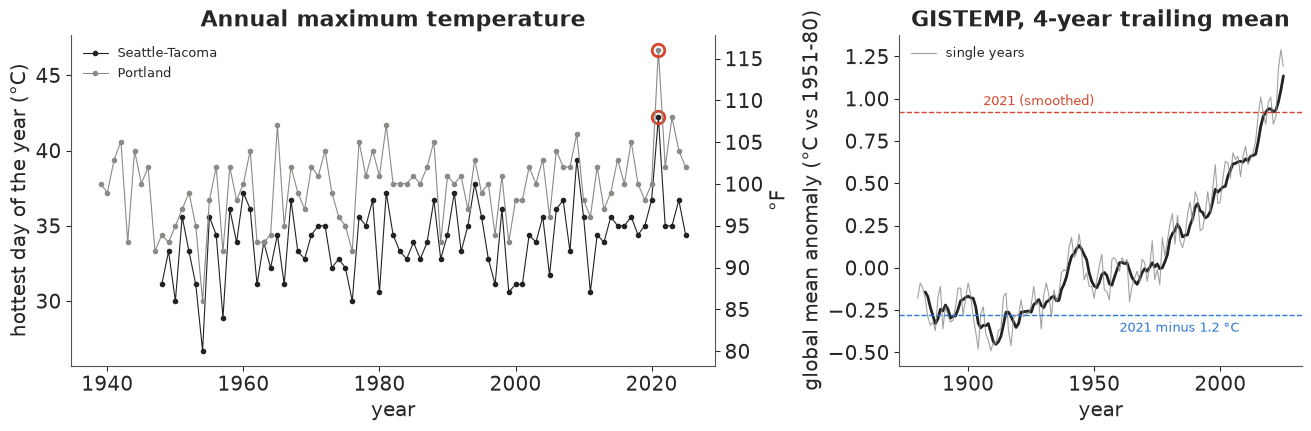

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
for df, name, col in [(sea, "Seattle-Tacoma", INK), (pdx, "Portland", GREY)]:
    ax.plot(df.index, df.tmax_c, "o-", ms=3, lw=0.8, color=col, label=name)
    ax.plot(2021, df.loc[2021, "tmax_c"], "o", ms=9, mfc="none", mec=NOW, mew=2)
ax.set(xlabel="year", ylabel="hottest day of the year (°C)", title="Annual maximum temperature")
ax.legend(loc="upper left", fontsize=9)
add_f_axis(ax, "y")
ax = axes[1]
ax.plot(gmst.index, gmst, color=INK, lw=2)
ax.plot(gis.index, gis["J-D"], color=GREY, lw=0.8, alpha=0.8, label="single years")
ax.axhline(T_2021, color=NOW, lw=1, ls="--")
ax.axhline(T_PAST, color=PAST, lw=1, ls="--")
ax.text(1950, T_2021 + 0.04, "2021 (smoothed)", color=NOW, fontsize=9, ha="right")
ax.text(1960, T_PAST - 0.1, "2021 minus 1.2 °C", color=PAST, fontsize=9)
ax.set(xlabel="year", ylabel="global mean anomaly (°C vs 1951-80)",
       title="GISTEMP, 4-year trailing mean")
ax.legend(loc="upper left", fontsize=9);

Two things to take from the left panel. Portland is about 3.5 °C hotter than Sea-Tac every
year, but the two series move together (same heatwaves); and both 2021 values are far
above anything before them. The right panel shows the one inconvenient fact about the
"past" climate: 2021 minus 1.2 °C is -0.28 °C, colder than any year we have station data
for (the coldest smoothed year in the Sea-Tac record is about -0.1 °C). Every statement
about the past climate is a modest **extrapolation** of the fitted trend, which is standard
in attribution but worth remembering.

> **In plain words:** Seattle's airport has a complete record of the hottest day of every year
> since 1948. The June 2021 day beat the old record by almost 3 °C (5 °F). Over the same
> period the whole planet warmed by about 1 °C.

## 2 · Extreme-value theory in five minutes

**Block maxima.** Whatever the distribution of daily temperatures, the maximum of a large
block of them (a year) is, after rescaling, approximately **generalised extreme value**
(GEV) distributed - the extreme-value analogue of the central limit theorem (Fisher-Tippett-
Gnedenko; Coles 2001, ch. 3). The GEV has a location $\mu$, a scale $\sigma$ and a shape
$\xi$:

$$P(Y \le y) = \exp\left\{-\left[1 + \xi\,\frac{y-\mu}{\sigma}\right]^{-1/\xi}\right\},
\qquad 1 + \xi\,\frac{y-\mu}{\sigma} > 0 .$$

**The shape is the hard part.** $\xi > 0$ gives a heavy upper tail (rainfall, floods,
insurance losses); $\xi = 0$ the Gumbel's exponential tail; and $\xi < 0$ a **finite upper
bound** at $\mu - \sigma/\xi$: values above it have probability *exactly zero*. Air
temperature is physically bounded, and fits to annual temperature maxima typically give
$\xi$ between about -0.1 and -0.4. That bound is where attribution gets interesting: with 78
data points, the bound is estimated from the handful of hottest years, and an event beyond
it is, according to the model, impossible.

**Which sign convention?** `pymc_extras.distributions.GenExtreme(mu, sigma, xi)` uses Coles'
$\xi$ (positive = heavy tail). `scipy.stats.genextreme(c, loc, scale)` uses $c = -\xi$. Mixing
them up flips a bounded tail into a heavy one, so we check the log-density and log-CDF
against SciPy before trusting either.

In [5]:
x_check = np.linspace(20, 45, 26)
for xi_test in [-0.3, -0.05, 0.2]:
    ref = stats.genextreme(c=-xi_test, loc=30, scale=2)
    lp = pm.logp(GenExtreme.dist(30.0, 2.0, xi_test), x_check).eval()
    lc = pm.logcdf(GenExtreme.dist(30.0, 2.0, xi_test), x_check).eval()
    ok_pdf = np.allclose(lp, ref.logpdf(x_check))
    ok_cdf = np.allclose(lc, ref.logcdf(x_check))
    print(f"xi = {xi_test:+.2f}: logp matches scipy {ok_pdf};  logcdf matches scipy {ok_cdf}")
    if not ok_cdf:
        bad = ~np.isclose(lc, ref.logcdf(x_check))
        print(f"   mismatch above the upper bound {30 - 2 / xi_test:.1f}: pymc_extras logcdf "
              f"{lc[bad][:2]}, scipy {ref.logcdf(x_check)[bad][:2]}")

xi = -0.30: logp matches scipy True;  logcdf matches scipy False
   mismatch above the upper bound 36.7: pymc_extras logcdf [-inf -inf], scipy [0. 0.]
xi = -0.05: logp matches scipy True;  logcdf matches scipy True
xi = +0.20: logp matches scipy True;  logcdf matches scipy True


The log-density matches for all three shapes, so the likelihood is safe to use. The
log-**CDF** does not: above the upper bound, where the CDF is 1 (log 0), `pymc_extras`
returns $-\infty$. It never matters for fitting (only `logp` is used), but it would silently
turn every "impossible" event into NaN if we used it for return periods. We compute
probabilities with our own NumPy functions below, written to handle the bound explicitly.

NumPy GEV helpers agree with scipy.stats.genextreme


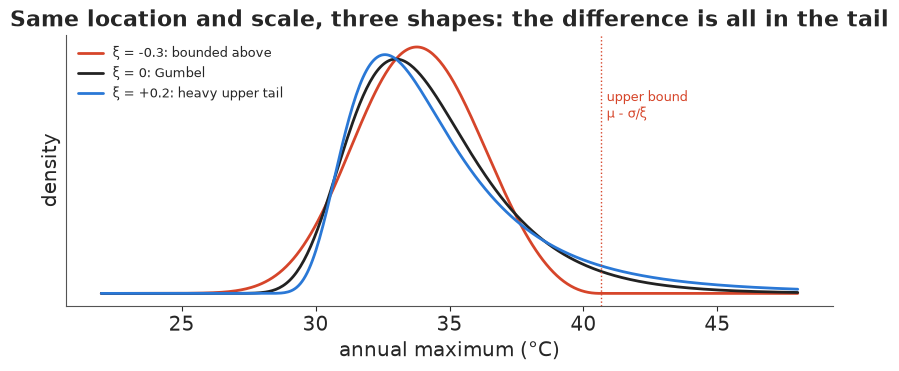

In [6]:
def gev_sf(x, mu, sigma, xi):
    """P(Y > x) for a GEV with Coles' shape xi; exactly 0 above an upper bound (xi < 0)."""
    arg = 1 + xi * (x - mu) / sigma
    with np.errstate(over="ignore", invalid="ignore"):
        sf = -np.expm1(-np.maximum(arg, 1e-300) ** (-1 / xi))
    return np.where(arg > 0, sf, np.where(xi < 0, 0.0, 1.0))


def gev_pdf(x, mu, sigma, xi):
    arg = 1 + xi * (x - mu) / sigma
    safe = np.maximum(arg, 1e-300)
    with np.errstate(over="ignore", invalid="ignore"):
        pdf = safe ** (-1 / xi - 1) * np.exp(-safe ** (-1 / xi)) / sigma
    return np.where(arg > 0, np.nan_to_num(pdf), 0.0)


def gev_return_level(period, mu, sigma, xi):
    """Level exceeded with probability 1/period in a year."""
    y_p = -np.log1p(-1 / period)
    return mu + sigma / xi * (y_p ** (-xi) - 1)


# The same checks for the NumPy versions, including above the bound.
for xi_test in [-0.3, 0.2]:
    ref = stats.genextreme(c=-xi_test, loc=30, scale=2)
    assert np.allclose(gev_sf(x_check, 30, 2, xi_test), ref.sf(x_check))
    assert np.allclose(gev_pdf(x_check, 30, 2, xi_test), ref.pdf(x_check))
    assert np.allclose(gev_return_level(np.array([10, 100]), 30, 2, xi_test), ref.isf([0.1, 0.01]))
print("NumPy GEV helpers agree with scipy.stats.genextreme")

fig, ax = plt.subplots(figsize=(8, 3.6))
xs = np.linspace(22, 48, 400)
for xi_test, col, lab in [(-0.3, NOW, "ξ = -0.3: bounded above"), (0.0, INK, "ξ = 0: Gumbel"),
                          (0.2, PAST, "ξ = +0.2: heavy upper tail")]:
    ax.plot(xs, stats.genextreme(c=-xi_test, loc=33, scale=2.3).pdf(xs), color=col, lw=2, label=lab)
ax.axvline(33 - 2.3 / -0.3, color=NOW, lw=1, ls=":")
ax.text(33 - 2.3 / -0.3 + 0.2, 0.12, "upper bound\nμ - σ/ξ", color=NOW, fontsize=9)
ax.set(xlabel="annual maximum (°C)", ylabel="density", yticks=[],
       title="Same location and scale, three shapes: the difference is all in the tail")
ax.legend(fontsize=9);

## 3 · Priors, and a prior predictive check in degrees

**Shape.** Martins & Stedinger (2000) proposed a "geophysical" prior for the GEV shape in
flood hydrology: a Beta(6, 9) on the shape shifted to $(-0.5, 0.5)$. It keeps $\xi$ away from
the absurd values a 50-year record can produce by maximum likelihood, and its centre (a
mildly heavy tail, $\xi \approx +0.1$ in our sign convention) suits floods. Temperature
maxima are bounded, so we keep the *form* - the same Beta(6, 9) on the same interval - but
mirror it to be centred on $\xi \approx -0.1$ (sd 0.12): most mass on bounded tails, but
Gumbel and mildly heavy tails still allowed. In section 7 we refit with the original flood
prior to see how much the answer depends on this choice.

**Location and trend.** The location is $\mu_t = \mu_0 + \alpha\,T_t$ where $T_t$ is the
smoothed global anomaly (°C vs 1951-80): $\mu_0$ is the typical hottest day in a 1951-80
climate, $\alpha$ is how many °C the local annual maximum moves per °C of global warming.
$\mu_0 \sim N(34, 4)$ °C (a mid-latitude summer maximum) and $\alpha \sim N(0, 2)$, centred
on *no* effect so that any warming signal comes from the data. **Scale** $\sigma \sim$
HalfNormal(3) °C, fixed over time (the WWA "shift" model: warming moves the whole
distribution without changing its spread or tail).

prior P(xi < 0) = 0.79; prior 5-95% of a year's maximum: 27 to 44 C; share of simulated years above 50 C: 0.011


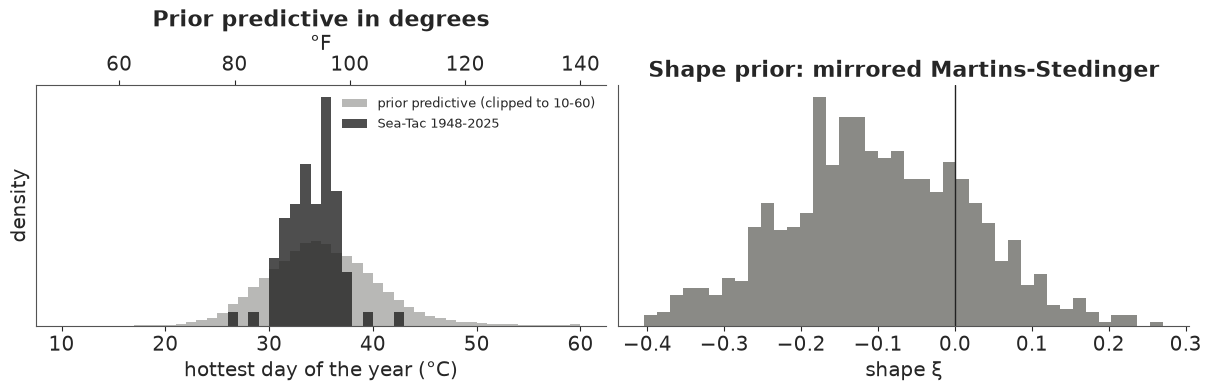

In [7]:
XI_A, XI_B = 6.0, 9.0  # mirrored Martins-Stedinger: xi + 0.5 ~ Beta(6, 9)

with pm.Model(coords={"year": sea.index}) as prior_model:
    mu0 = pm.Normal("mu0", 34, 4)
    alpha = pm.Normal("alpha", 0, 2)
    sigma = pm.HalfNormal("sigma", 3)
    xi = pm.Deterministic("xi", pm.Beta("b", XI_A, XI_B) - 0.5)
    mu = mu0 + alpha * sea.gmst.to_numpy()
    GenExtreme("y", mu, sigma, xi, dims="year")
    prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)

y_prior = prior.prior["y"].to_numpy().ravel()
xi_prior = prior.prior["xi"].to_numpy().ravel()
print(f"prior P(xi < 0) = {(xi_prior < 0).mean():.2f}; prior 5-95% of a year's maximum: "
      f"{np.quantile(y_prior, 0.05):.0f} to {np.quantile(y_prior, 0.95):.0f} C; "
      f"share of simulated years above 50 C: {(y_prior > 50).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.hist(np.clip(y_prior, 10, 60), bins=np.arange(10, 60.5, 1), density=True, color=GREY, alpha=0.6,
        label="prior predictive (clipped to 10-60)")
ax.hist(sea.tmax_c, bins=np.arange(10, 60.5, 1), density=True, color=INK, alpha=0.8, label="Sea-Tac 1948-2025")
ax.set(xlabel="hottest day of the year (°C)", ylabel="density", yticks=[], title="Prior predictive in degrees")
ax.legend(fontsize=9)
add_f_axis(ax)
ax = axes[1]
ax.hist(xi_prior, bins=40, color=GREY, density=True)
ax.axvline(0, color=INK, lw=1)
ax.set(xlabel="shape ξ", yticks=[], title="Shape prior: mirrored Martins-Stedinger");

The prior predictive puts 90% of simulated hottest days between about 27 and 44 °C (80 and
111 °F), with a thin tail of silly values (about 1% above 50 °C) - wide enough to learn from the data, narrow
enough to exclude a Seattle summer peaking at 70 °C. The observed maxima sit comfortably
inside it.

## 4 · The support wall: why a naive GEV fit diverges

Start with the simplest model, a **stationary** GEV (no trend), fitted to Sea-Tac *without*
2021 (section 6 explains why the event year is left out). Straight into PyMC:

In [8]:
keep = sea.index != 2021
y_sea, T_sea = sea.tmax_c.to_numpy(), sea.gmst.to_numpy()


def mirrored_ms_shape(name="xi", a=XI_A, b=XI_B):
    return pm.Deterministic(name, pm.Beta(f"{name}_beta", a, b) - 0.5)


with pm.Model() as naive_model:
    mu0 = pm.Normal("mu0", 34, 4)
    sigma = pm.HalfNormal("sigma", 3)
    xi = mirrored_ms_shape()
    GenExtreme("y", mu0, sigma, xi, observed=y_sea[keep])
    naive_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

n_div = int(naive_idata.sample_stats["diverging"].sum())
print(f"divergences: {n_div} of 4000")
az.summary(naive_idata, var_names=["mu0", "sigma", "xi"], round_to=3)

divergences: 339 of 4000


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,33.128,0.288,32.651,33.590,2311.937,2396.511,1.001,0.006,0.005
sigma,2.376,0.180,2.113,2.680,2135.252,2187.505,1.000,0.004,0.003
xi,-0.293,0.050,-0.367,-0.208,1868.881,1681.278,1.002,0.001,0.001


Hundreds of divergences, in a three-parameter model with 77 data points. Why? nutpie
records *why* each divergent trajectory was abandoned in `sample_stats["divergence_message"]`.

In [9]:
ss = naive_idata.sample_stats
why = pd.Series(ss["divergence_message"].to_numpy().ravel().astype(str))[ss["diverging"].to_numpy().ravel()]
print(why.str.replace(r"[-\d.]+$", "", regex=True).value_counts().to_string())

Logp function returned error code:        311
Divergence due to large energy error:      28


Almost all of them are "the log-density returned an error": the leapfrog step jumped to
parameters where some observation lies *outside the support* ($\log p = -\infty$). With
$\xi < 0$ each parameter draw implies an upper bound $\mu - \sigma/\xi$, which must lie above
the hottest observation (39.4 °C). The posterior lives right next to that wall, and near it the
log-likelihood falls like $(-1/\xi - 1)\log(\text{bound} - y_{\max})$: a log-barrier that
steepens without limit. (Where a divergent draw is *stored* is not where the trajectory
failed, so a scatter plot of divergent draws would not show this.) The left panel below is
the log-likelihood along $\sigma$ with $\mu$ and $\xi$ held at their posterior medians.

at the posterior medians mu0 = 33.1, xi = -0.30: the wall is at sigma = 1.86 C


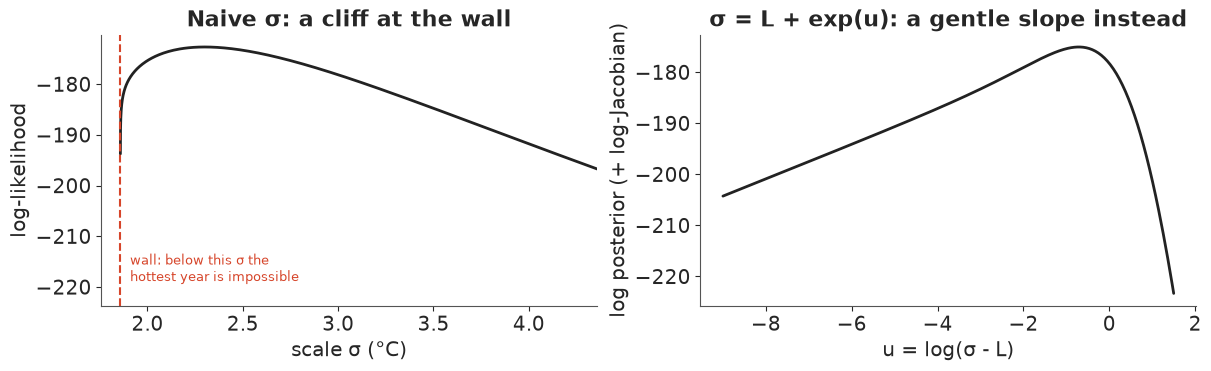

In [10]:
pn = az.extract(naive_idata)
mu_m, xi_m = float(pn["mu0"].median()), float(pn["xi"].median())
y_fit = y_sea[keep]
L_m = max(0.0, np.max(xi_m * (mu_m - y_fit)))  # smallest sigma that keeps every year inside
u_grid = np.linspace(-9, 1.5, 300)
sig_grid = L_m + np.exp(u_grid)
loglik = np.array([stats.genextreme.logpdf(y_fit, c=-xi_m, loc=mu_m, scale=s_).sum() for s_ in sig_grid])
log_post_u = loglik + stats.halfnorm.logpdf(sig_grid, scale=3) + u_grid  # + log-Jacobian

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(sig_grid, loglik, color=INK, lw=2)
axes[0].axvline(L_m, color=NOW, lw=1.5, ls="--")
axes[0].text(L_m + 0.03, loglik.min() * 0.95 + loglik.max() * 0.05, " wall: below this σ the\n hottest year is impossible",
             color=NOW, fontsize=9)
axes[0].set(xlim=(L_m - 0.1, L_m + 2.5), xlabel="scale σ (°C)", ylabel="log-likelihood",
            title="Naive σ: a cliff at the wall")
axes[1].plot(u_grid, log_post_u, color=INK, lw=2)
axes[1].set(xlabel="u = log(σ - L)", ylabel="log posterior (+ log-Jacobian)",
            title="σ = L + exp(u): a gentle slope instead")
print(f"at the posterior medians mu0 = {mu_m:.1f}, xi = {xi_m:.2f}: the wall is at sigma = {L_m:.2f} C")

The fix is a reparametrisation that makes the wall unreachable. For any $\mu_t$ and $\xi$, every
observation stays inside the support if and only if

$$\sigma > L(\mu, \xi) = \max\bigl(0, \max_t\, \xi\,(\mu_t - y_t)\bigr).$$

So sample $u \in \mathbb{R}$ and set $\sigma = L + e^{u}$. The prior stays HalfNormal(3) on
$\sigma$: we add its log-density plus the log-Jacobian $u$ as a `pm.Potential` (the map from
$(\mu_0, \alpha, \xi, u)$ to $(\mu_0, \alpha, \xi, \sigma)$ is triangular, so the Jacobian is
just $d\sigma/du = e^u$). The posterior is *exactly* the same; only the coordinates changed,
and in them the wall is at $u = -\infty$, where the log-density is now a gentle linear slope.

In [11]:
def gev_block(prefix, y, T, xi, event=None, sigma_sd=3.0):
    """Non-stationary GEV for one station inside the current model.

    mu_t = mu0 + alpha * T_t; sigma = L + exp(u) keeps every observation inside the support.
    `event` = (y_event, T_event, selection_threshold or None) adds the event year as a Potential,
    optionally divided by P(Y > threshold) (the event was only studied because it broke the record).
    Pass T=None for a stationary model.
    """
    mu0 = pm.Normal(f"{prefix}mu0", 34, 4)
    alpha = 0.0 if T is None else pm.Normal(f"{prefix}alpha", 0, 2)
    mu = mu0 + (0.0 if T is None else alpha * T) + np.zeros(len(y))
    ys, mus = y, mu
    if event is not None:
        y_ev, T_ev, u_sel = event
        mu_ev = mu0 + alpha * T_ev
        ys, mus = np.r_[y, y_ev], pt.concatenate([mu, pt.stack([mu_ev])])
    lower = pt.maximum(0.0, pt.max(xi * (mus - ys)))
    u = pm.Flat(f"{prefix}log_excess")
    sigma = pm.Deterministic(f"{prefix}sigma", lower + pt.exp(u))
    pm.Potential(f"{prefix}sigma_prior", pm.logp(pm.HalfNormal.dist(sigma_sd), sigma) + u)
    GenExtreme(f"{prefix}y", mu, sigma, xi, observed=y)
    if event is not None:
        lp = pm.logp(GenExtreme.dist(mu_ev, sigma, xi), y_ev)
        if u_sel is not None:  # log P(Y > u) at the event year's climate
            t_sel = pt.pow(1 + xi * (u_sel - mu_ev) / sigma, -1 / xi)
            lp = lp - pt.log(-pt.expm1(-t_sel))
        pm.Potential(f"{prefix}event", lp)


def fit_station(y, T, event=None, xi_ab=(XI_A, XI_B), seed=RANDOM_SEED):
    with pm.Model() as model:
        xi = mirrored_ms_shape(a=xi_ab[0], b=xi_ab[1])
        gev_block("", y, T, xi, event=event)
        idata = pm.sample(random_seed=seed, progressbar=False, target_accept=0.9,
                          initvals={"log_excess": 0.0, "mu0": 33.0})
    return model, idata


def report(idata, var_names):
    print(f"divergences: {int(idata.sample_stats['diverging'].sum())}, "
          f"tuning steps: {idata.posterior.attrs.get('tuning_steps')}")
    return az.summary(idata, var_names=var_names, round_to=3)


stat_model, stat_idata = fit_station(y_sea[keep], None)
report(stat_idata, ["mu0", "sigma", "xi"])

divergences: 1, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,33.118,0.286,32.649,33.566,2281.718,2065.034,1.004,0.006,0.005
sigma,2.375,0.184,2.101,2.686,3671.260,2274.219,1.002,0.003,0.003
xi,-0.290,0.053,-0.367,-0.198,902.582,819.132,1.003,0.002,0.002


The same posterior (compare the table with the naive one) and the divergences are
essentially gone. The stationary fit already has a clearly negative shape, $\xi \approx
-0.29$: a bounded tail.

## 5 · The non-stationary model: the distribution shifts with global temperature

Now the location follows smoothed global temperature. Still without 2021.

In [12]:
ns_model, ns_idata = fit_station(y_sea[keep], T_sea[keep])
report(ns_idata, ["mu0", "alpha", "sigma", "xi"])

divergences: 0, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,32.615,0.341,32.068,33.148,1999.202,2319.643,1.000,0.008,0.005
alpha,1.855,0.703,0.714,2.943,1949.326,2390.031,1.000,0.016,0.011
sigma,2.251,0.177,1.986,2.549,4804.591,3588.829,1.001,0.003,0.003
xi,-0.288,0.056,-0.371,-0.191,1135.465,1563.883,1.005,0.002,0.001


The hottest day of the year at Sea-Tac moves by $\alpha \approx 1.9$ °C per °C of global
warming, with a wide 89% interval (about 0.7 to 3.0): Pacific Northwest summer maxima
warm faster than the global mean, as land does, but one station's 77 years pin the rate
down only loosely. $\alpha$ is clearly positive; everything that follows inherits its width.

**Does the trend earn its place?** LOO compares the stationary and non-stationary fits on
the same 77 years.

In [13]:
for idata, model in [(stat_idata, stat_model), (ns_idata, ns_model)]:
    with model:
        pm.compute_log_likelihood(idata, var_names=["y"], progressbar=False)
cmp = az.compare({"stationary": stat_idata, "shift with GMST": ns_idata}, round_to=1)
cmp

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
shift with GMST,0,0.0,0.0,NaN,,1 k̂ > 0.70,3.5,-172.8,6.9,1.0
stationary,1,-3.1,1.9,1.0,N < 100,,3.1,-175.9,7.3,0.0


PSIS flags at least one year with Pareto $\hat k > 0.7$: its importance weights cannot be
trusted. That is expected for a GEV - the hottest years sit next to the ceiling, and leaving
one out moves the ceiling a lot. With 77 points and 5-second fits, the honest fix is to refit
without each flagged year and compute its leave-one-out density exactly.

In [14]:
def gev_logpdf_draws(y_i, T_i, idata):
    mu0, alpha, sigma, xi = draws(idata)
    lp = stats.genextreme.logpdf(y_i, c=-xi, loc=mu0 + alpha * T_i, scale=sigma)
    return np.logaddexp.reduce(lp) - np.log(len(lp))  # log mean density over draws


def draws(idata, prefix="", n=None):
    p = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED) if n else az.extract(idata)
    alpha = p[f"{prefix}alpha"].to_numpy() if f"{prefix}alpha" in p else 0.0
    return p[f"{prefix}mu0"].to_numpy(), alpha, p[f"{prefix}sigma"].to_numpy(), p["xi"].to_numpy()


elpd_i = {}
for name, idata, has_T in [("stationary", stat_idata, False), ("shift with GMST", ns_idata, True)]:
    loo = az.loo(idata, pointwise=True)
    ei, k = loo.elpd_i.to_numpy().copy(), loo.pareto_k.to_numpy()
    for i in np.where(k > 0.7)[0]:
        mask = np.arange(len(y_fit)) != i
        _, refit = fit_station(y_fit[mask], T_sea[keep][mask] if has_T else None)
        ei[i] = gev_logpdf_draws(y_fit[i], T_sea[keep][i] if has_T else 0.0, refit)
        print(f"{name}: year {sea.index[keep][i]} ({y_fit[i]} C) k = {k[i]:.2f}: "
              f"PSIS {loo.elpd_i.to_numpy()[i]:.2f} -> exact {ei[i]:.2f}")
    elpd_i[name] = ei
diff = elpd_i["shift with GMST"] - elpd_i["stationary"]
print(f"elpd: stationary {elpd_i['stationary'].sum():.1f}, shift {elpd_i['shift with GMST'].sum():.1f}; "
      f"difference {diff.sum():.1f} +- {np.sqrt(len(diff) * diff.var()):.1f} (se)")

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


shift with GMST: year 2009 (39.4 C) k = 0.79: PSIS -4.56 -> exact -4.61
elpd: stationary -175.9, shift -172.8; difference 3.1 +- 1.9 (se)


Only 2009 (the hottest year before 2021, sitting next to the ceiling) is flagged, and its exact
leave-one-out term is almost the same as the PSIS one. The shift model is ahead
by about 3 points of elpd with a standard error of about 2: modest evidence that the
distribution moves with global temperature. One station's 77 noisy maxima cannot do much
better; the physical case for the covariate (and a trend whose posterior is clearly above zero) carries
as much weight as the score.

**Posterior predictive checks.** Two views. (1) A **return-level plot** in 2021's climate:
each observed year is shifted to 2021's global temperature with the fitted trend
($y_t + \hat\alpha\,(T_{2021} - T_t)$), sorted, and plotted at its empirical return period
$(n+1)/\text{rank}$, on top of the fitted return-level curve with its 90% band. (2) The
**PIT**: each year's observation passed through its own year's fitted CDF should look
uniform.

PIT: 0.09 of years above 0.9, 0.13 below 0.1


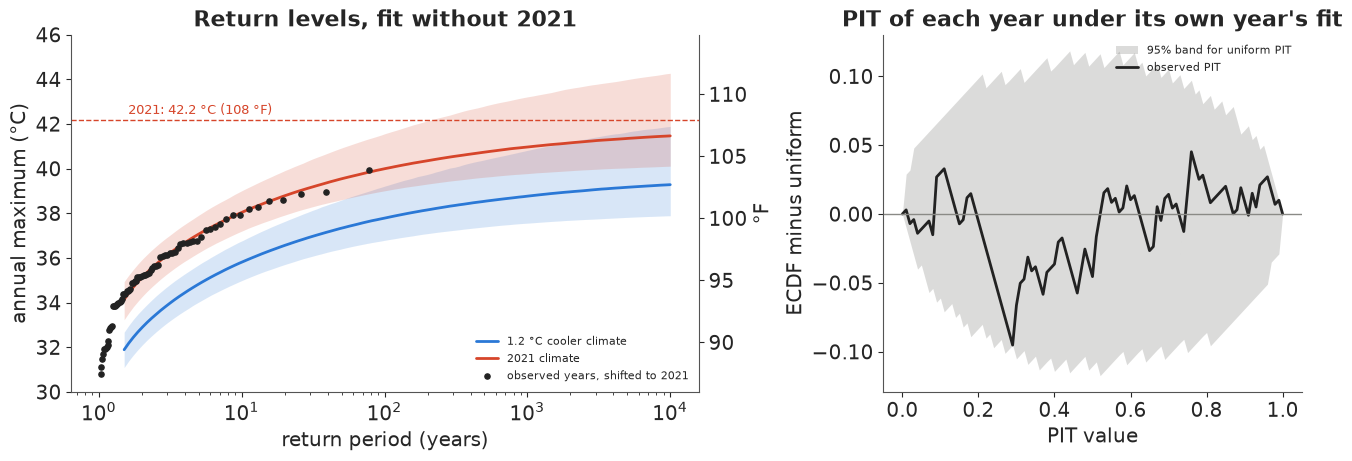

In [15]:
periods = np.geomspace(1.5, 10_000, 120)


def return_level_panel(ax, idata, y, T, title, event_c=None, prefix=""):
    mu0, alpha, sigma, xi = draws(idata, prefix)
    for T_c, col, lab in [(T_PAST, PAST, "1.2 °C cooler climate"), (T_2021, NOW, "2021 climate")]:
        rl = gev_return_level(periods[:, None], mu0 + alpha * T_c, sigma, xi)
        lo, med, hi = np.quantile(rl, [0.05, 0.5, 0.95], axis=1)
        ax.fill_between(periods, lo, hi, color=col, alpha=0.18, lw=0)
        ax.plot(periods, med, color=col, lw=2, label=lab)
    shifted = np.sort(y + np.mean(alpha) * (T_2021 - T))[::-1]
    emp = (len(y) + 1) / np.arange(1, len(y) + 1)
    ax.scatter(emp, shifted, s=14, color=INK, zorder=3, label="observed years, shifted to 2021")
    if event_c is not None:
        ax.axhline(event_c, color=NOW, lw=1, ls="--")
        ax.text(1.6, event_c + 0.25, f"2021: {event_c:.1f} °C ({c_to_f(event_c):.0f} °F)", color=NOW, fontsize=9)
    ax.set(xscale="log", xlabel="return period (years)", ylabel="annual maximum (°C)", title=title)
    ax.legend(loc="lower right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.5, 1]})
return_level_panel(axes[0], ns_idata, y_sea[keep], T_sea[keep], "Return levels, fit without 2021",
                   event_c=EVENT_C["Sea-Tac"])
axes[0].set_ylim(30, 46)
add_f_axis(axes[0], "y")

mu0, alpha, sigma, xi = draws(ns_idata)
cdf = 1 - gev_sf(y_sea[keep][:, None], mu0 + alpha * T_sea[keep][:, None], sigma, xi)
pit = cdf.mean(axis=1)  # posterior predictive PIT of each year
ax = axes[1]
u_grid = np.linspace(0, 1, 101)
ecdf = (pit[:, None] <= u_grid).mean(axis=0)
unif_ecdf = (rng.uniform(size=(2000, len(pit)))[:, :, None] <= u_grid).mean(axis=1)
lo_b, hi_b = np.quantile(unif_ecdf - u_grid, [0.025, 0.975], axis=0)
ax.fill_between(u_grid, lo_b, hi_b, color=GREY, alpha=0.3, lw=0, label="95% band for uniform PIT")
ax.plot(u_grid, ecdf - u_grid, color=INK, lw=2, label="observed PIT")
ax.axhline(0, color=GREY, lw=1)
ax.set(xlabel="PIT value", ylabel="ECDF minus uniform", title="PIT of each year under its own year's fit")
ax.legend(fontsize=8)
print(f"PIT: {np.mean(pit > 0.9):.2f} of years above 0.9, {np.mean(pit < 0.1):.2f} below 0.1")

The shifted observations follow the fitted 2021-climate curve across the whole range, and
the PIT's ECDF stays inside the uniform band: the model describes the 77 years it saw.
Then look at the dashed line. **108 °F is above the median return-level curve at every
return period, even 10,000 years**, in both climates: the curves flatten out towards their
upper bound below it. For just over half of the posterior draws the June 2021 day is not rare,
it is outside the distribution altogether. This is the attribution problem this event
became famous for, and the next section faces it.

> **In plain words:** Before 2021, Sea-Tac's records looked like a climate with a ceiling - a
> hottest possible day - for about half of the explanations that fit, below 42 °C (108 °F) even
> in today's climate. Warming has been raising that ceiling
> by about 2 °C for every 1 °C of global warming. Then 2021 went through it.

## 6 · Attribution: probability ratio, return period, intensity change

For each posterior draw compute, in the 2021 climate and in one 1.2 °C cooler,

- $p_1 = P(Y > 42.2\,°C \mid T_{2021})$ and $p_0 = P(Y > 42.2\,°C \mid T_{2021} - 1.2)$;
- the **return period** $1/p$ in each climate (infinite when $p = 0$);
- the **probability ratio** $\mathrm{PR} = p_1 / p_0$: $\infty$ when the event is possible now
  but not in the past climate, and *undefined* when it is impossible in both;
- the **intensity change** $\Delta I$: how much hotter an event of the same rarity is now. In
  the shift model this is simply $1.2\,\alpha$, the same for every return period.

**Should 2021 be in the data?** Attribution protocols usually leave the event year *out*,
because the event is the reason we are looking: an analysis triggered by a record, then fitted
to data including that record, overstates how likely records are (selection bias). But
leaving it out throws away a hard fact - the ceiling in 2021's climate *is* above 42.2 °C,
because it happened. We fit three versions and compare:

1. **without 2021** (the protocol);
2. **with 2021** as an ordinary year (the naive fix);
3. **with 2021, corrected for selection**: the event year enters as its density *given that it
   broke the previous record*, $f(y_{2021}) / P(Y > 39.4\,°C)$. The study was triggered by a
   record, so the likelihood of the trigger year is conditional on being a record. This keeps
   the fact that 42.2 °C is attainable (the support constraint) while discounting the "it
   happened, so it must be likely" information. (Selection bias in rapid attribution is
   analysed properly by Miralles & Davison 2023; this is the simplest version of the idea.)

In [16]:
y_ev = EVENT_C["Sea-Tac"]
_, with_idata = fit_station(y_sea[keep], T_sea[keep], event=(y_ev, T_2021, None))
print("with 2021:", end=" ")
display(report(with_idata, ["mu0", "alpha", "sigma", "xi"]))
_, sel_idata = fit_station(y_sea[keep], T_sea[keep], event=(y_ev, T_2021, RECORD_BEFORE["Sea-Tac"]))
print("with 2021, selection-corrected:", end=" ")
report(sel_idata, ["mu0", "alpha", "sigma", "xi"])

with 2021: divergences: 1, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,32.426,0.364,31.848,33.010,1967.680,2146.178,1.002,0.008,0.007
alpha,2.402,0.722,1.244,3.534,1861.455,2248.294,1.002,0.017,0.014
sigma,2.341,0.192,2.062,2.665,4626.601,2870.461,1.001,0.003,0.003
xi,-0.213,0.051,-0.291,-0.128,1276.761,1637.257,1.003,0.001,0.001


with 2021, selection-corrected: divergences: 0, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,32.432,0.352,31.857,32.975,1856.164,2150.735,1.001,0.008,0.006
alpha,2.235,0.729,1.058,3.387,1801.439,2194.205,1.001,0.017,0.012
sigma,2.308,0.189,2.025,2.627,3935.777,3131.110,1.001,0.003,0.003
xi,-0.214,0.051,-0.288,-0.128,908.352,1163.969,1.004,0.002,0.001


In [17]:
def attribution(idata, event_c, prefix="", T_now=T_2021, dT=DT):
    """Per-draw attribution quantities for an event of `event_c` deg C."""
    mu0, alpha, sigma, xi = draws(idata, prefix)
    mu_now, mu_past = mu0 + alpha * T_now, mu0 + alpha * (T_now - dT)
    p1, p0 = gev_sf(event_c, mu_now, sigma, xi), gev_sf(event_c, mu_past, sigma, xi)
    with np.errstate(divide="ignore", invalid="ignore"):
        pr = np.where((p1 == 0) & (p0 == 0), np.nan, p1 / p0)
    return dict(p_now=p1, p_past=p0, pr=pr, delta=alpha * dT,
                bound_now=np.where(xi < 0, mu_now - sigma / xi, np.inf),
                bound_past=np.where(xi < 0, mu_past - sigma / xi, np.inf), xi=xi, alpha=alpha)


def q_inf(x, q):
    """Quantile that treats +inf as a value (no interpolation into NaN)."""
    x = x[~np.isnan(x)]
    return np.quantile(x, q, method="inverted_cdf")


def summarise(att):
    pr = att["pr"]
    rp_now = np.where(att["p_now"] > 0, 1 / np.maximum(att["p_now"], 1e-300), np.inf)
    return {
        "shape ξ (median)": np.median(att["xi"]),
        "P(impossible in 2021 climate)": np.mean(att["p_now"] == 0),
        "P(impossible 1.2 °C cooler)": np.mean(att["p_past"] == 0),
        "return period now: median (yr)": q_inf(rp_now, 0.5),
        "return period now: 5% (yr)": q_inf(rp_now, 0.05),
        "PR: share infinite": np.mean(np.isinf(pr)),
        "PR: share undefined (0/0)": np.mean(np.isnan(pr)),
        "PR: 5% quantile": q_inf(pr, 0.05),
        "PR: median (∞ counted)": q_inf(pr, 0.5),
        "PR: median of finite draws": np.median(pr[np.isfinite(pr)]) if np.isfinite(pr).any() else np.nan,
        "ΔI median (°C)": np.median(att["delta"]),
        "ΔI 5-95% (°C)": f"{np.quantile(att['delta'], 0.05):.1f} to {np.quantile(att['delta'], 0.95):.1f}",
    }


att = {name: attribution(idata, y_ev) for name, idata in
       [("without 2021", ns_idata), ("with 2021", with_idata), ("with 2021, selection-corrected", sel_idata)]}
table = pd.DataFrame({k: summarise(v) for k, v in att.items()})


def fmt(v):
    if isinstance(v, str):
        return v
    if np.isinf(v):
        return "∞"
    if np.isnan(v):
        return "-"
    return f"{v:.2f}" if abs(v) < 10 else f"{v:,.0f}"


table.map(fmt)

,without 2021,with 2021,"with 2021, selection-corrected"
shape ξ (median),-0.29,-0.22,-0.22
P(impossible in 2021 climate),0.56,0.00,0.00
P(impossible 1.2 °C cooler),0.88,0.43,0.46
return period now: median (yr),∞,284,418
return period now: 5% (yr),216,52,64
PR: share infinite,0.33,0.43,0.46
PR: share undefined (0/0),0.55,0.00,0.00
PR: 5% quantile,13,6.35,5.46
PR: median (∞ counted),∞,"23,516","160,708"
PR: median of finite draws,121,85,69


Read the table column by column.

- **Without 2021**, the fit says 108 °F was impossible *even in 2021's climate* in over half
  of the posterior draws (and in almost 9 draws out of 10 in the cooler climate). A model
  that calls the observed event impossible has been falsified by it; those draws give no
  probability ratio at all (0/0, "undefined"). This is the honest cost of the protocol for
  an event this far out.
- **With 2021**, every draw lets the event happen now (it has to, since it did). Including it
  also makes the tail less bounded ($\xi$ moves from about -0.29 to -0.22) and the trend a
  little steeper. In the cooler world the event is impossible in over 40% of draws - an
  **infinite** probability ratio - and where it was possible the ratio is still large.
- **Selection-corrected**, the shape barely moves compared with "with 2021" and the trend
  comes down a little, while the return period in today's climate grows (from under 300 to
  over 400 years at the median): the correction removes some of the evidence that such days
  are common while keeping the evidence that they are possible. The share of infinite
  probability ratios stays in the mid-40s per cent.

The "median (∞ counted)" row shows why a single number is the wrong summary: when almost
half the draws are infinite, the median lands in the far tail of the finite ones.

We use the **selection-corrected** fit from here on. The next figure shows *why* the answer
is a mix of infinite and finite ratios: it is the posterior of the ceiling.

P(PR > 10) = 0.91, P(PR > 100) = 0.70 (infinite counts as larger)


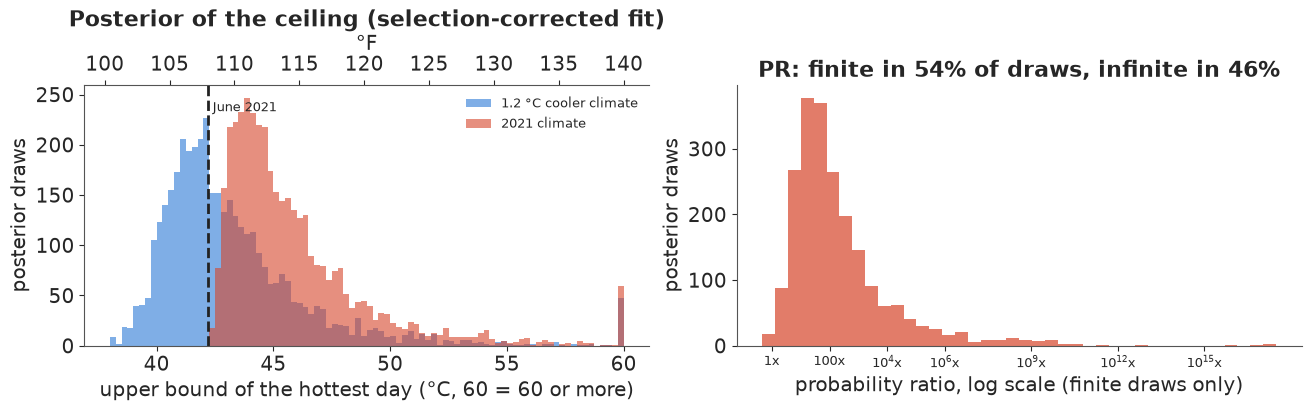

In [18]:
a_sel = att["with 2021, selection-corrected"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
bins = np.linspace(38, 60, 89)
ax.hist(np.clip(a_sel["bound_past"], 38, 60), bins=bins, color=PAST, alpha=0.6, label="1.2 °C cooler climate")
ax.hist(np.clip(a_sel["bound_now"], 38, 60), bins=bins, color=NOW, alpha=0.6, label="2021 climate")
ax.axvline(y_ev, color=INK, lw=2, ls="--")
ax.text(y_ev + 0.2, ax.get_ylim()[1] * 0.9, "June 2021", fontsize=9)
ax.set(xlabel="upper bound of the hottest day (°C, 60 = 60 or more)", ylabel="posterior draws",
       title="Posterior of the ceiling (selection-corrected fit)")
ax.legend(fontsize=9)
add_f_axis(ax)
ax = axes[1]
pr = a_sel["pr"]
finite = pr[np.isfinite(pr)]
ax.hist(np.log10(finite), bins=40, color=NOW, alpha=0.7)
ax.set(xlabel="log10 probability ratio (finite draws only)", ylabel="posterior draws",
       title=f"PR: finite in {np.isfinite(pr).mean():.0%} of draws, infinite in {np.isinf(pr).mean():.0%}")
ax.set_xticks([0, 2, 4, 6, 9, 12, 15])
ax.set_xticklabels(["1x", "100x", "$10^4$x", "$10^6$x", "$10^9$x", "$10^{12}$x", "$10^{15}$x"], fontsize=9)
ax.set_xlabel("probability ratio, log scale (finite draws only)")
print(f"P(PR > 10) = {np.mean(pr > 10):.2f}, P(PR > 100) = {np.mean(pr > 100):.2f} (infinite counts as larger)")

In the 2021 climate the ceiling is necessarily above 42.2 °C (the fit was told the event
happened). Shift the same draws 1.2 °C cooler and the ceiling moves down by $1.2\,\alpha$,
about 2.6 °C, which drops a large share of it *below* 42.2 °C: that share is exactly the
share of infinite probability ratios. The right panel shows the rest. A single summary
number would hide this mixture, so report the parts: *in a little under half of the plausible
worlds the old climate could not produce this day at all; in the rest, warming typically made
it tens to hundreds of times more likely, with a long tail of far larger ratios* (the
right-hand histogram spans more than ten orders of magnitude, because a probability that is
merely tiny in the past climate is the same thing, statistically, as a ceiling just above
42.2 °C).

**Intensity change and return levels.**

intensity change: median 2.7 C (4.9 F), 90% 1.2 to 4.1 C; P(delta > 0) = 0.997


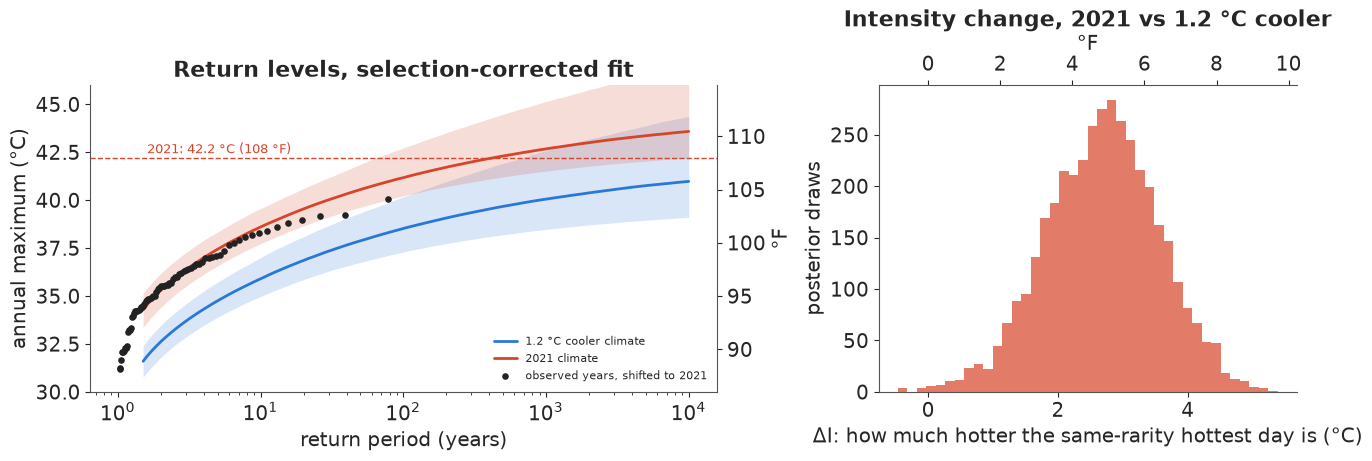

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.5, 1]})
return_level_panel(axes[0], sel_idata, y_sea[keep], T_sea[keep], "Return levels, selection-corrected fit",
                   event_c=y_ev)
axes[0].set_ylim(30, 46)
add_f_axis(axes[0], "y")
ax = axes[1]
ax.hist(a_sel["delta"], bins=40, color=NOW, alpha=0.7)
ax.set(xlabel="ΔI: how much hotter the same-rarity hottest day is (°C)", ylabel="posterior draws",
       title="Intensity change, 2021 vs 1.2 °C cooler")
sec = ax.secondary_xaxis("top", functions=(lambda c: c * 9 / 5, lambda f: f * 5 / 9))  # a difference: no +32
sec.set_xlabel("°F")
d_q = np.quantile(a_sel["delta"], [0.05, 0.5, 0.95])
print(f"intensity change: median {d_q[1]:.1f} C ({d_q[1] * 9 / 5:.1f} F), 90% {d_q[0]:.1f} to {d_q[2]:.1f} C; "
      f"P(delta > 0) = {np.mean(a_sel['delta'] > 0):.3f}")

A 1-in-100-year hottest day is now roughly 2-3 °C hotter than it would have been in the
cooler climate, and the same holds at every return period (the two curves are parallel:
that is the shift model's assumption, not a finding). The 2021 line now crosses the median
2021-climate curve, at a return period of a few hundred years, instead of passing above it.

> **In plain words:** In today's climate a day like 28 June 2021 is still extremely rare at
> Sea-Tac - a few hundred years between such days on average, though it could be as often as
> every 60-odd years. In a world 1.2 °C cooler it was, in almost half of the explanations that
> fit the data, flatly impossible; in the rest it was far rarer still. Heatwaves of any given
> rarity now run about 2.7 °C (5 °F) hotter.

## 7 · How much does the shape prior matter?

The share of "impossible" draws is a statement about the upper tail, which the data inform
weakly. Refit the selection-corrected model with the original Martins-Stedinger *flood* prior
(centred on a heavy tail, $\xi \approx +0.1$).

In [20]:
_, flood_idata = fit_station(y_sea[keep], T_sea[keep], event=(y_ev, T_2021, RECORD_BEFORE["Sea-Tac"]),
                             xi_ab=(XI_B, XI_A))
display(report(flood_idata, ["alpha", "sigma", "xi"]))
att_flood = attribution(flood_idata, y_ev)
pd.DataFrame({"mirrored (temperature) prior": summarise(a_sel),
              "original flood prior": summarise(att_flood)}).map(fmt)

divergences: 0, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,2.173,0.724,1.000,3.327,1805.325,1891.809,1.001,0.017,0.012
sigma,2.280,0.181,2.008,2.588,4038.082,3139.120,1.000,0.003,0.003
xi,-0.179,0.052,-0.255,-0.089,1169.938,1373.812,1.005,0.002,0.001


,mirrored (temperature) prior,original flood prior
shape ξ (median),-0.22,-0.18
P(impossible in 2021 climate),0.00,0.00
P(impossible 1.2 °C cooler),0.46,0.23
return period now: median (yr),418,236
return period now: 5% (yr),64,45
PR: share infinite,0.46,0.23
PR: share undefined (0/0),0.00,0.00
PR: 5% quantile,5.46,3.44
PR: median (∞ counted),"160,708",92
PR: median of finite draws,69,33


The flood prior pulls $\xi$ towards zero (median about -0.18 instead of -0.22), which raises
the ceiling: the share of "impossible in the past" draws halves, from about 46% to 23%,
today's return period shortens (median about 240 instead of 420 years) and the finite
probability ratios shrink (median about 30 instead of 70). The intensity change barely moves. So: **the
direction and size of the warming effect are robust; how often the past climate is judged to
have a hard ceiling below 2021, and how rare 2021 is today, depend on the tail prior**, and
should be reported with it. With 77 years, the data alone cannot settle the upper tail.

## 8 · Replication: Portland, and a shape shared by both stations

Portland's 2021 maximum (46.7 °C, 116 °F) beat its previous record (41.7 °C) by 5 °C - even
further out than Seattle's. Same model, same selection correction. Then a joint model with
**one shape** for both stations (separate locations, trends and scales): the two airports
share a climate and physically similar upper tails, and a shared $\xi$ borrows information
about the tail. A caveat: the two series are strongly correlated (the same heatwaves hit
both), and the joint likelihood treats them as independent given the parameters, so it
somewhat overstates how much the second station adds.

In [21]:
keep_p = pdx.index != 2021
y_pdx, T_pdx = pdx.tmax_c.to_numpy(), pdx.gmst.to_numpy()
_, pdx_idata = fit_station(y_pdx[keep_p], T_pdx[keep_p], event=(EVENT_C["Portland"], T_2021, RECORD_BEFORE["Portland"]))
display(report(pdx_idata, ["mu0", "alpha", "sigma", "xi"]))
att_pdx = attribution(pdx_idata, EVENT_C["Portland"])

with pm.Model() as joint_model:
    xi = mirrored_ms_shape()
    gev_block("sea_", y_sea[keep], T_sea[keep], xi, event=(y_ev, T_2021, RECORD_BEFORE["Sea-Tac"]))
    gev_block("pdx_", y_pdx[keep_p], T_pdx[keep_p], xi,
              event=(EVENT_C["Portland"], T_2021, RECORD_BEFORE["Portland"]))
    joint_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9,
                            initvals={"sea_log_excess": 0.0, "pdx_log_excess": 0.0,
                                      "sea_mu0": 33.0, "pdx_mu0": 36.0})
display(report(joint_idata, ["xi", "sea_alpha", "pdx_alpha", "sea_sigma", "pdx_sigma"]))
att_joint = {"Sea-Tac": attribution(joint_idata, y_ev, prefix="sea_"),
             "Portland": attribution(joint_idata, EVENT_C["Portland"], prefix="pdx_")}
pd.DataFrame({"Sea-Tac alone": summarise(a_sel), "Portland alone": summarise(att_pdx),
              "Sea-Tac, shared ξ": summarise(att_joint["Sea-Tac"]),
              "Portland, shared ξ": summarise(att_joint["Portland"])}).map(fmt)

divergences: 1, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu0,35.924,0.327,35.403,36.453,2209.718,2121.594,1.002,0.007,0.005
alpha,2.430,0.692,1.297,3.521,1977.560,2161.749,1.001,0.016,0.011
sigma,2.337,0.180,2.069,2.638,4322.449,3175.621,1.000,0.003,0.003
xi,-0.190,0.044,-0.256,-0.114,1224.146,1259.065,1.002,0.001,0.001


divergences: 0, tuning steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
xi,-0.210,0.033,-0.259,-0.156,1395.943,1603.685,1.000,0.001,0.001
sea_alpha,2.165,0.718,1.026,3.322,2555.693,2623.508,1.001,0.014,0.012
pdx_alpha,2.479,0.696,1.340,3.560,2647.289,2598.925,1.002,0.014,0.012
sea_sigma,2.291,0.178,2.027,2.586,5675.064,3893.449,1.000,0.002,0.002
pdx_sigma,2.361,0.181,2.091,2.666,4553.203,3469.733,1.001,0.003,0.003


,Sea-Tac alone,Portland alone,"Sea-Tac, shared ξ","Portland, shared ξ"
shape ξ (median),-0.22,-0.19,-0.21,-0.21
P(impossible in 2021 climate),0.00,0.00,0.00,0.00
P(impossible 1.2 °C cooler),0.46,0.40,0.39,0.58
return period now: median (yr),418,602,427,962
return period now: 5% (yr),64,88,76,137
PR: share infinite,0.46,0.40,0.39,0.58
PR: share undefined (0/0),0.00,0.00,0.00,0.00
PR: 5% quantile,5.46,6.90,6.73,17
PR: median (∞ counted),"160,708","12,288","8,370",∞
PR: median of finite draws,69,102,131,446


Portland replicates the story: a trend of about 2.4 °C per °C of global warming, an
intensity change near 3 °C, a large share of infinite probability ratios (40% on its own) and
a 2021 return period of several hundred years even in today's climate. The shared shape
(sd 0.03 instead of 0.05) sits between the two stations' own estimates. Because Portland's
jump over its old record was larger (5 °C against 2.8 °C), sharing a slightly more bounded
shape pushes Portland's "impossible in the past" share up to over half and its return
period towards a thousand years, while Sea-Tac's drops to about 40%.

> **In plain words:** Portland tells the same story as Seattle. Its 116 °F would have been
> impossible in the cooler climate for somewhere between four and six in ten of the
> explanations that fit its records, depending on how much we let the two cities share.

## 9 · Explaining it to everyone

Everything below is computed from the selection-corrected Sea-Tac fit. Four displays, each
for a different question a non-statistician asks, and each showing the uncertainty as
something to count or watch rather than a band to decode. We use 100 °F as a second,
everyday threshold: it has been reached at Sea-Tac in only three summers since 1948, and it is
not near the ceiling, so its odds are much better determined than those of 108 °F.

In [22]:
mu0, alpha, sigma, xi = draws(sel_idata)
T100 = float(f_to_c(100.0))
climates = {"1.2 °C cooler world": T_PAST, "2021 climate": T_2021, "2025 climate": T_2025}
p100 = {k: gev_sf(T100, mu0 + alpha * T, sigma, xi) for k, T in climates.items()}
p108 = {k: gev_sf(y_ev, mu0 + alpha * T, sigma, xi) for k, T in climates.items()}
print("observed summers >= 100 F:", list(sea.index[sea.tmax_c >= 37.75]))
for k in climates:
    print(f"{k:>20}: P(100 F in a summer) median {np.median(p100[k]):.3f} "
          f"(80%: {np.quantile(p100[k], 0.1):.3f}-{np.quantile(p100[k], 0.9):.3f}); "
          f"P(108 F) median {np.median(p108[k]):.4f} (80%: {np.quantile(p108[k], 0.1):.4f}-"
          f"{np.quantile(p108[k], 0.9):.4f}), impossible in {np.mean(p108[k] == 0):.0%}")

observed summers >= 100 F: [1994, 2009, 2021]
 1.2 °C cooler world: P(100 F in a summer) median 0.022 (80%: 0.007-0.050); P(108 F) median 0.0000 (80%: 0.0000-0.0006), impossible in 46%
        2021 climate: P(100 F in a summer) median 0.167 (80%: 0.110-0.242); P(108 F) median 0.0024 (80%: 0.0002-0.0109), impossible in 0%
        2025 climate: P(100 F in a summer) median 0.217 (80%: 0.135-0.323); P(108 F) median 0.0051 (80%: 0.0008-0.0184), impossible in 0%


### 9.1 "Loaded dice": out of 1,000 summers

An icon array turns a probability into a count of things - here 1,000 summers, one square
each, coloured when that summer has at least one 100 °F day at the airport. The number of
coloured squares is the median chance; the caption gives the likely range in words.

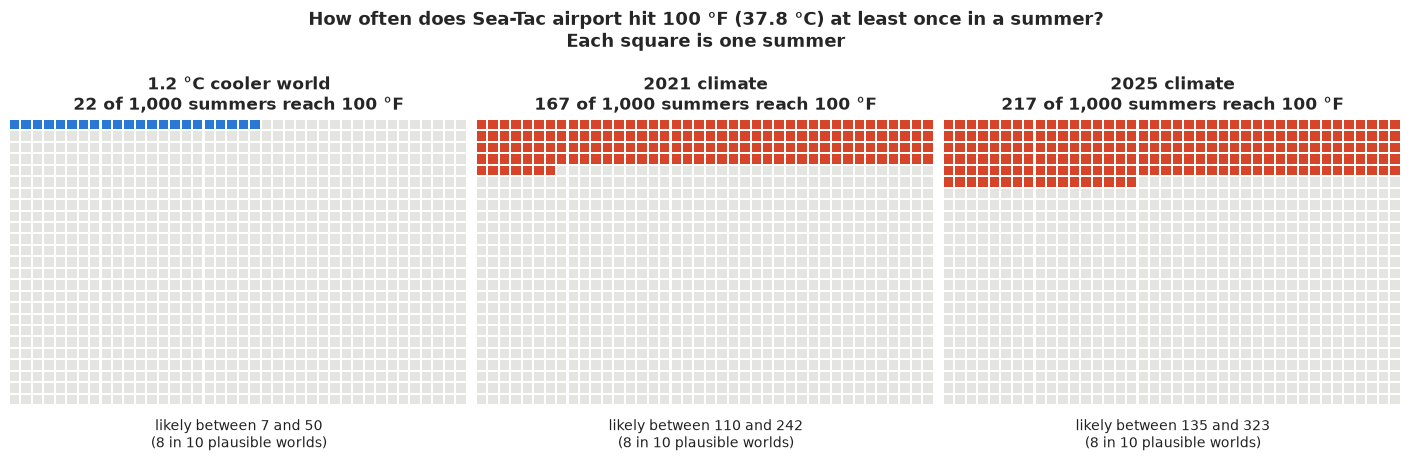

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (k, p) in zip(axes, p100.items()):
    n_hot = int(round(1000 * np.median(p)))
    lo, hi = (int(round(1000 * v)) for v in np.quantile(p, [0.1, 0.9]))
    col = PAST if "cooler" in k else NOW
    for i in range(1000):
        r, c = divmod(i, 40)
        ax.add_patch(Rectangle((c, 24 - r), 0.82, 0.82, color=col if i < n_hot else "#e4e4e0", lw=0))
    ax.set(xlim=(0, 40), ylim=(0, 25), xticks=[], yticks=[], aspect="equal")
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f"{k}\n{n_hot} of 1,000 summers reach 100 °F", fontsize=12)
    ax.text(20, -1.2, f"likely between {lo} and {hi}\n(8 in 10 plausible worlds)", ha="center",
            va="top", fontsize=10, color=INK)
fig.suptitle("How often does Sea-Tac airport hit 100 °F (37.8 °C) at least once in a summer?\n"
             "Each square is one summer", fontsize=13);

**Why it works:** people read counts of things (frequency framing) far more accurately than
percentages, and three grids side by side make "loaded dice" literal - the same 1,000
summers, more of them hot. **What it hides:** the uncertainty is only in the caption; each
grid shows one number (the median). And the "2025 climate" is a climate held fixed at 2025's
temperature, not a forecast.

### 9.2 "During a 30-year mortgage"

A yearly probability is abstract; "the chance of at least one such day while you own this
house" is a question people actually have. For a climate held at 2025 levels (a floor: it
will keep warming), chance of at least one day at 100 °F and at 108 °F in 30 summers,
$1 - (1-p)^{30}$, per posterior draw.

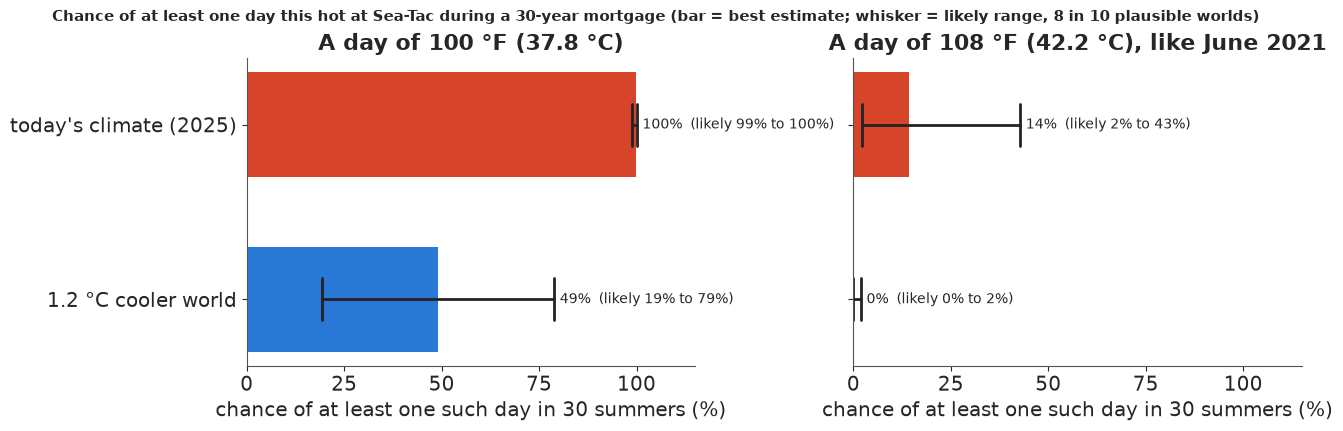

In [24]:
def at_least_once(p, years=30):
    return 1 - (1 - p) ** years


rows = [("100 °F (37.8 °C)", p100), ("108 °F (42.2 °C), like June 2021", p108)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (label, pdict) in zip(axes, rows):
    for j, (k, T) in enumerate([("1.2 °C cooler world", PAST), ("2025 climate", NOW)]):
        chance = at_least_once(pdict[k])
        lo, med, hi = np.quantile(chance, [0.1, 0.5, 0.9])
        ax.barh(j, med * 100, color=T, height=0.6)
        ax.plot([lo * 100, hi * 100], [j, j], color=INK, lw=2)
        ax.plot([lo * 100] * 2, [j - 0.12, j + 0.12], color=INK, lw=2)
        ax.plot([hi * 100] * 2, [j - 0.12, j + 0.12], color=INK, lw=2)
        ax.text(max(hi, med) * 100 + 1.5, j, f"{med:.0%}  (likely {lo:.0%} to {hi:.0%})", va="center", fontsize=10)
    ax.set(yticks=[0, 1], yticklabels=["1.2 °C cooler world", "today's climate (2025)"], xlim=(0, 115),
           xlabel="chance of at least one such day in 30 summers (%)", title=f"A day of {label}")
    ax.set_xticks([0, 25, 50, 75, 100])
fig.suptitle("Chance of at least one day this hot at Sea-Tac during a 30-year mortgage "
             "(bar = best estimate; whisker = likely range, 8 in 10 plausible worlds)", fontsize=11);

**Why it works:** it answers a decision-shaped question on a scale everyone knows
(0-100%), and the whisker is labelled in words. **What it hides:** it holds the climate
fixed for 30 years, which understates the risk; and for 108 °F the "likely range" of the
cooler world starts at exactly zero, which the bar cannot distinguish from "very small".

### 9.3 The hottest day of the year, decade by decade (animation)

Press play: each frame is the distribution of the hottest day of the year at Sea-Tac under
the global temperature of that year (a 1.2 °C-cooler world first, then 1950 to 2025),
averaging over 400 plausible explanations of the data. The shaded tail beyond 100 °F is the
chance of a 100 °F summer, printed in the title; the red line is June 2021.

In [25]:
mu0_s, alpha_s, sigma_s, xi_s = draws(sel_idata, n=400)
x_f = np.linspace(80, 115, 351)
x_c = f_to_c(x_f)
frame_T = [("a world 1.2 °C cooler than 2021", T_PAST)] + [(str(yr), float(gmst.loc[yr])) for yr in range(1950, 2026, 3)] + [("2025", T_2025)]
dens = [gev_pdf(x_c[:, None], mu0_s + alpha_s * T, sigma_s, xi_s).mean(axis=1) * 5 / 9 for _, T in frame_T]
p100_frames = [np.median(gev_sf(T100, mu0_s + alpha_s * T, sigma_s, xi_s)) for _, T in frame_T]

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=72)
ymax = max(d.max() for d in dens) * 1.1
(line,) = ax.plot(x_f, dens[0], color=INK, lw=2)
fill = [ax.fill_between(x_f, 0, np.where(x_f >= 100, dens[0], 0), color=NOW, alpha=0.5, lw=0)]
ax.axvline(108, color=NOW, lw=2)
ax.text(108.3, ymax * 0.85, "28 June 2021\n108 °F", color=NOW, fontsize=10)
ax.axvline(100, color=GREY, lw=1, ls=":")
ax.set(xlim=(80, 115), ylim=(0, ymax), yticks=[], xlabel="hottest day of the year at Sea-Tac (°F)",
       ylabel="how likely")
title = ax.set_title("", fontsize=12)
plt.close(fig)


def update(i):
    line.set_ydata(dens[i])
    fill[0].remove()
    fill[0] = ax.fill_between(x_f, 0, np.where(x_f >= 100, dens[i], 0), color=NOW, alpha=0.5, lw=0)
    name = frame_T[i][0]
    lead = "A 1.2 °C cooler world" if not name.isdigit() else f"Climate of {name}"
    title.set_text(f"{lead}: 100 °F in about {p100_frames[i] * 100:.0f} of 100 summers")
    return line, title


anim = animation.FuncAnimation(fig, update, frames=len(frame_T), interval=500, blit=False)
HTML(anim.to_jshtml(default_mode="once"))

**Why it works:** watching the hump slide to the right is the most direct picture of "the
whole distribution shifts", and the tail beyond 100 °F visibly grows. The red line stays
in empty space in the early frames and only meets a visible sliver of the curve in the last
ones, which is what "record-shattering" means.
**What it hides:** it shows the *average* distribution over plausible explanations, so the
uncertainty in the trend and the ceiling is blended into one curve; the probability in the
title is a median. Like every animation it cannot be printed: 9.1 is its static partner.

### 9.4 "How much hotter is a heatwave now?" - twenty equally likely answers

A quantile dotplot shows the intensity change as 20 dots, each an equally likely answer:
"count the dots" replaces reading a density. Below it, the same 20 plausible worlds answer
the yes/no question "could the cooler world have produced 108 °F at all?"

intensity change (F): 20 quantile dots [1.6 2.5 3.  3.4 3.6 3.9 4.1 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.3 6.6
 7.1 7.8]


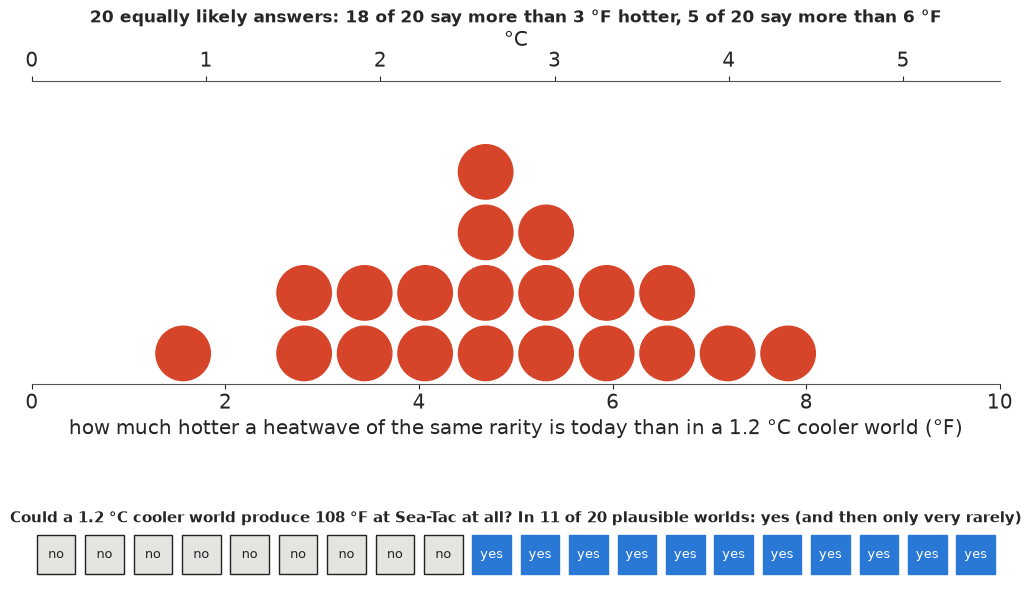

In [26]:
def quantile_dotplot(ax, samples, n_dots=20, n_bins=16, color=NOW, xlim=None):
    q = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    lo, hi = xlim
    edges = np.linspace(lo, hi, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(q, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for c in cols:
        ax.add_patch(Ellipse((edges[c] + width / 2, (heights[c] + 0.5) * width), width * 0.9, width * 0.9, color=color))
        heights[c] += 1
    ax.set(xlim=(lo, hi), ylim=(0, (heights.max() + 1) * width), yticks=[], aspect="equal")
    for s in ["left", "right", "top"]:
        ax.spines[s].set_visible(False)
    return q


delta_f = a_sel["delta"] * 9 / 5
fig = plt.figure(figsize=(11, 6.2), layout="none")  # hand-placed axes
ax = fig.add_axes([0.06, 0.42, 0.88, 0.5])
q = quantile_dotplot(ax, delta_f, xlim=(0, 10))
ax.set_xlabel("how much hotter a heatwave of the same rarity is today than in a 1.2 °C cooler world (°F)")
ax.set_title(f"20 equally likely answers: {int((q > 3).sum())} of 20 say more than 3 °F hotter, "
             f"{int((q > 6).sum())} of 20 say more than 6 °F", fontsize=12)
sec = ax.secondary_xaxis("top", functions=(lambda f: f * 5 / 9, lambda c: c * 9 / 5))
sec.set_xlabel("°C")

ax2 = fig.add_axes([0.06, 0.04, 0.88, 0.22])
worlds = np.quantile(a_sel["bound_past"], (np.arange(20) + 0.5) / 20)  # 20 equally likely ceilings
for i, b in enumerate(worlds):
    possible = b > y_ev
    ax2.add_patch(Rectangle((i + 0.1, 0.1), 0.8, 0.8, color=PAST if possible else "#e4e4e0",
                            ec=INK if not possible else PAST, lw=1))
    ax2.text(i + 0.5, 0.5, "yes" if possible else "no", ha="center", va="center", fontsize=9,
             color="white" if possible else INK)
n_poss = int((worlds > y_ev).sum())
ax2.set(xlim=(0, 20), ylim=(0, 1), xticks=[], yticks=[], aspect="equal")
for s in ax2.spines.values():
    s.set_visible(False)
ax2.set_title(f"Could a 1.2 °C cooler world produce 108 °F at Sea-Tac at all? "
              f"In {n_poss} of 20 plausible worlds: yes (and then only very rarely)", fontsize=11)
print(f"intensity change (F): 20 quantile dots {np.round(q, 1)}")

**Why it works:** twenty dots make "likely range" concrete - five dots is one in four - and
the yes/no strip turns the awkward infinite probability ratio into a plain count of worlds.
**What it hides:** the dotplot rounds the distribution to 20 values, and the strip says
nothing about *how* rare the event was in the "yes" worlds (section 6 does).

### 9.5 Export for a web page

A compact JSON of the lay-relevant results: a few hundred posterior draws of the key
quantities, return-level curves as quantiles, the shifting-climate curve by year, and a
one-sentence headline per quantity.

In [27]:
def r(x, nd=4):
    x = np.asarray(x, dtype=float)
    return [None if not np.isfinite(v) else round(float(v), nd) for v in x.ravel()]


idx = rng.choice(len(a_sel["pr"]), 400, replace=False)
years_grid = np.arange(1950, 2026)
p100_by_year = np.stack([gev_sf(T100, mu0 + alpha * gmst.loc[yr], sigma, xi) for yr in years_grid])
rl_now = gev_return_level(periods[:, None], mu0 + alpha * T_2021, sigma, xi)
rl_past = gev_return_level(periods[:, None], mu0 + alpha * T_PAST, sigma, xi)
pr_sel = a_sel["pr"]
export = {
    "id": "E37",
    "title": "How much did warming load the dice for the 2021 Pacific Northwest heatwave?",
    "station": "Seattle-Tacoma International Airport (NOAA GHCN-Daily USW00024233)",
    "model": "non-stationary GEV (location shifts with 4-yr smoothed GISTEMP global temperature), "
             "fitted 1948-2025 with 2021 corrected for selection",
    "event": {"date": "2021-06-28", "value_c": y_ev, "value_f": round(float(c_to_f(y_ev)), 1),
              "previous_record_c": RECORD_BEFORE["Sea-Tac"], "portland_value_c": EVENT_C["Portland"]},
    "climates": {"past": {"label": "1.2 °C cooler than 2021", "gmst_anomaly_c": round(T_PAST, 3)},
                 "2021": {"gmst_anomaly_c": round(T_2021, 3)}, "2025": {"gmst_anomaly_c": round(T_2025, 3)}},
    "observed": {"year": sea.index.tolist(), "annual_max_c": r(sea.tmax_c, 1)},
    "draws": {
        "n": len(idx),
        "note": "equally likely posterior draws; null = infinite (pr) or undefined",
        "p108_past": r(p108["1.2 °C cooler world"][idx], 6), "p108_2021": r(p108["2021 climate"][idx], 6),
        "p108_2025": r(p108["2025 climate"][idx], 6),
        "p100_past": r(p100["1.2 °C cooler world"][idx]), "p100_2021": r(p100["2021 climate"][idx]),
        "p100_2025": r(p100["2025 climate"][idx]),
        "pr_108": r(pr_sel[idx], 2), "pr_108_is_infinite": np.isinf(pr_sel[idx]).tolist(),
        "intensity_change_c": r(a_sel["delta"][idx], 3),
        "ceiling_past_c": r(a_sel["bound_past"][idx], 2), "ceiling_2021_c": r(a_sel["bound_now"][idx], 2),
    },
    "return_levels": {"return_period_years": r(periods, 2), "quantiles": [0.05, 0.5, 0.95],
                      "now_2021_c": [r(np.quantile(rl_now, q, axis=1), 2) for q in [0.05, 0.5, 0.95]],
                      "past_c": [r(np.quantile(rl_past, q, axis=1), 2) for q in [0.05, 0.5, 0.95]]},
    "p100_by_year": {"year": years_grid.tolist(), "quantiles": [0.1, 0.5, 0.9],
                     "p": [r(np.quantile(p100_by_year, q, axis=1)) for q in [0.1, 0.5, 0.9]]},
    "summary": {
        "share_impossible_past": round(float(np.mean(p108["1.2 °C cooler world"] == 0)), 3),
        "share_pr_infinite": round(float(np.mean(np.isinf(pr_sel))), 3),
        "pr_median_finite_draws": round(float(np.median(pr_sel[np.isfinite(pr_sel)])), 1),
        "return_period_2021_median_years": round(float(1 / np.median(p108["2021 climate"])), 0),
        "intensity_change_c_q05_q50_q95": r(np.quantile(a_sel["delta"], [0.05, 0.5, 0.95]), 2),
        "p100_per_summer_median": {k: round(float(np.median(v)), 3) for k, v in p100.items()},
    },
}
export["headlines"] = {
    "impossible_past": f"In about {export['summary']['share_impossible_past']:.0%} of the explanations that fit "
                       "Sea-Tac's records, a 108 °F day could not happen at all in a world 1.2 °C cooler.",
    "probability_ratio": "Where it could happen, warming made it many times more likely (median about "
                         f"{export['summary']['pr_median_finite_draws']:.0f} times).",
    "return_period": f"Even in 2021's climate a day like 28 June 2021 is expected about once in "
                     f"{round(export['summary']['return_period_2021_median_years'], -2):,.0f} years at Sea-Tac, "
                     "with a very wide range.",
    "intensity": f"A heatwave of the same rarity is now about {d_q[1] * 9 / 5:.0f} °F ({d_q[1]:.1f} °C) hotter "
                 "than in a 1.2 °C cooler world.",
    "p100": f"A 100 °F day now comes in about {np.median(p100['2025 climate']):.0%} of summers, against about "
            f"{np.median(p100['1.2 °C cooler world']):.0%} in the cooler world.",
}
out = Path("../../.scratch/artifact/E37.json")
if not out.parent.exists():  # the build runs in notebooks/examples; fall back to the repo root
    out = Path(".scratch/artifact/E37.json")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, ensure_ascii=False, separators=(",", ":")))
print(f"wrote {out} ({out.stat().st_size / 1024:.0f} KB)")
print(json.dumps(export["headlines"], indent=1, ensure_ascii=False))

wrote ../../.scratch/artifact/E37.json (38 KB)
{
 "impossible_past": "In about 46% of the explanations that fit Sea-Tac's records, a 108 °F day could not happen at all in a world 1.2 °C cooler.",
 "probability_ratio": "Where it could happen, warming made it many times more likely (median about 70 times).",
 "return_period": "Even in 2021's climate a day like 28 June 2021 is expected about once in 400 years at Sea-Tac, with a very wide range.",
 "intensity": "A heatwave of the same rarity is now about 5 °F (2.7 °C) hotter than in a 1.2 °C cooler world.",
 "p100": "A 100 °F day now comes in about 22% of summers, against about 2% in the cooler world."
}


The page export above keeps a few hundred draws. The interactive Lumen reports in `reports/`
use the **full posterior** instead: every chain and draw of the fitted parameters, plus the
quantities derived from them over all the draws they were computed on
(`reports/posteriors/E37.nc`, see `reports/README.md`).

In [28]:
from pymc_challenges.export import save_posterior

CLIMATES = ["past climate (1.2 C cooler)", "2021 climate", "2025 climate"]
save_posterior("E37", sel_idata, {
    "p_108F_per_summer": (("sample", "climate"), np.column_stack(list(p108.values())), {"climate": CLIMATES},
                          "probability per summer", "chance a summer has a day of 108 F (42.2 C) or hotter"),
    "p_100F_per_summer": (("sample", "climate"), np.column_stack(list(p100.values())), {"climate": CLIMATES},
                          "probability per summer", "chance a summer has a day of 100 F (37.8 C) or hotter"),
    "probability_ratio_108F": (("sample",), np.where(np.isfinite(pr_sel), pr_sel, np.nan), {}, "ratio",
                               "how many times more likely a 108 F day is in 2021 than in the past climate; "
                               "NaN where it was impossible in the past climate (infinite) or in both"),
    "intensity_change_c": (("sample",), a_sel["delta"], {}, "degrees C",
                           "how much hotter a heatwave of the same rarity is in 2021 than in the past climate"),
    "ceiling_c": (("sample", "climate"), np.column_stack([a_sel["bound_past"], a_sel["bound_now"]]),
                  {"climate": CLIMATES[:2]}, "degrees C", "hottest possible day under the fitted GEV (upper bound)"),
    "return_level_c": (("sample", "climate", "return_period_years"), np.stack([rl_past.T, rl_now.T], axis=1),
                       {"climate": CLIMATES[:2], "return_period_years": periods}, "degrees C",
                       "hottest day expected once in N years"),
    "p_100F_by_year": (("sample", "year"), p100_by_year.T, {"year": years_grid}, "probability per summer",
                       "chance of a 100 F day in each year's climate"),
}, x_dims=("return_period_years", "year"));

wrote reports/posteriors/E37.nc: 6 parameters x 4000 draws; 7 derived quantities; 10.6 MB


## 10 · What we learned

- **Block maxima + GEV** is the standard model for "the hottest day of the year"; the shape
  parameter decides whether there is a ceiling, and temperature data say there is.
- The **support wall** makes a naive GEV fit diverge; sampling the scale as "the minimum it
  must be, plus a positive excess" gives the same posterior without the divergences.
- Letting the location follow **global temperature** is supported by LOO; Sea-Tac's hottest
  day warms about 2 °C per °C of global warming, with a wide range.
- **Whether the event year is in the data** changes the answer more than any prior: without
  it, the model calls the observed event impossible in over half of its draws. Correcting
  for selection is a principled middle way.
- The **probability ratio** is a mixture of finite values and infinity, and the infinite part
  depends on the shape prior. Report the share of infinite draws, not a single number.

## Try it yourself

1. **Scale that scales.** Replace the fixed scale with $\sigma_t = \sigma_0 \exp(\alpha\,T_t /
   \mu_0)$ (WWA's "fit that scales with location", used for rainfall) and see whether LOO
   prefers it and whether the probability ratio moves. The support reparametrisation needs
   $L$ computed per year.
2. **A regional maximum.** WWA averaged over a region (45-52 °N, 119-123 °W) rather than one
   airport. Add more GHCN stations from the region, fit them with a shared shape and a
   hierarchical trend, and see how much the regional $\alpha$ tightens.
3. **A different trigger.** The selection correction assumed the study was triggered by
   "a new record". Try "any year above 40 °C" as the trigger instead, and report how
   sensitive the return period is to what you assume made you look.